# Customer Sales Data Analysis Project

## Import Libraries

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

### Load Dataset

In [86]:
df = pd.read_csv("customer_sales_data.csv")
#Load Datasets - 5columns
print(df.head())

  Customer_ID  Gender  Age Region Product_Category  Units_Purchased  \
0     CUST001    Male   32  South           Beauty                2   
1     CUST002  Female   20  North      Electronics                2   
2     CUST003    Male   53  South           Beauty                4   
3     CUST004  Female   55   East      Electronics                9   
4     CUST005  Female   27  South  Home Appliances                3   

   Price_Per_Unit Purchase_Date  Total_Amount  
0             404    2025-03-12           808  
1            4667    2025-01-23          9334  
2            2105    2025-05-10          8420  
3            3636    2025-02-26         32724  
4            3662    2025-03-29         10986  


### Show Column Names, Data Types and Datasets

In [87]:
#Column Name
print("----Column Names----")
print(df.columns)

#Data Types
print("----Data Types----")
print(df.dtypes)

#Data Shapes
print("----Data Shapes----")
print(df.shape)

----Column Names----
Index(['Customer_ID', 'Gender', 'Age', 'Region', 'Product_Category',
       'Units_Purchased', 'Price_Per_Unit', 'Purchase_Date', 'Total_Amount'],
      dtype='str')
----Data Types----
Customer_ID           str
Gender                str
Age                 int64
Region                str
Product_Category      str
Units_Purchased     int64
Price_Per_Unit      int64
Purchase_Date         str
Total_Amount        int64
dtype: object
----Data Shapes----
(150, 9)


### Convert Purchase data to DateType

In [88]:
print("-----Purchase Date to Datetime Type-----")

df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])

print(df["Purchase_Date"].head())

-----Purchase Date to Datetime Type-----
0   2025-03-12
1   2025-01-23
2   2025-05-10
3   2025-02-26
4   2025-03-29
Name: Purchase_Date, dtype: datetime64[us]


### Use Numpy Calculations

In [89]:
print("-----Average Total Amount-----")

avg_total = np.mean(df["Total_Amount"])
print(avg_total)

print("-----Units Purchased-----")

avg_units = np.mean(df["Units_Purchased"])
print("Average Units Purchased:", avg_units)

print("-----Highest Purchase-----")

highest_purchase = np.max(df["Total_Amount"])
print("Highest Purchase Amount:", highest_purchase)

print("-----Lowest Purchase-----")
lowest_purchase = np.min(df["Total_Amount"])
print("Lowest Purchased Amount:", lowest_purchase)

-----Average Total Amount-----
14076.7
-----Units Purchased-----
Average Units Purchased: 5.326666666666667
-----Highest Purchase-----
Highest Purchase Amount: 49200
-----Lowest Purchase-----
Lowest Purchased Amount: 646


## Data Analysis

In [79]:
print("-----Group Total Sales by Gender-----")
gender_sales = df.groupby("Gender")["Total_Amount"].sum()
print(gender_sales)

-----Group Total Sales by Gender-----
Gender
Female    1038330
Male      1073175
Name: Total_Amount, dtype: int64


In [80]:
print("-----Group Total Sales by Region-----")
region_sales = df.groupby("Region")["Total_Amount"].sum()
print(region_sales)

-----Group Total Sales by Region-----
Region
East     436971
North    435164
South    617682
West     621688
Name: Total_Amount, dtype: int64


In [81]:
print("-----Group Total Sales by Product Category-----")
product_sales = df.groupby("Product_Category")["Total_Amount"].sum()
print(product_sales)

-----Group Total Sales by Product Category-----
Product_Category
Beauty             244965
Books              383951
Clothing           474286
Electronics        305179
Home Appliances    355529
Sports             347595
Name: Total_Amount, dtype: int64


In [82]:
print("-----Month-wise Total Purchases-----")
df["Month"]=df["Purchase_Date"].dt.month
monthly_sales = df.groupby("Month")["Total_Amount"].sum()
print(monthly_sales)

-----Month-wise Total Purchases-----
Month
1    441043
2    341587
3    345928
4    224591
5    454699
6    303657
Name: Total_Amount, dtype: int64


## Visualization

### Plot a bar chart of total sales by Product Category.

In [68]:

category_sales = df.groupby("Product_Category")["Total_Amount"].sum()
print(category_sales)


Product_Category
Beauty             244965
Books              383951
Clothing           474286
Electronics        305179
Home Appliances    355529
Sports             347595
Name: Total_Amount, dtype: int64


Text(0, 0.5, 'Total Sales')

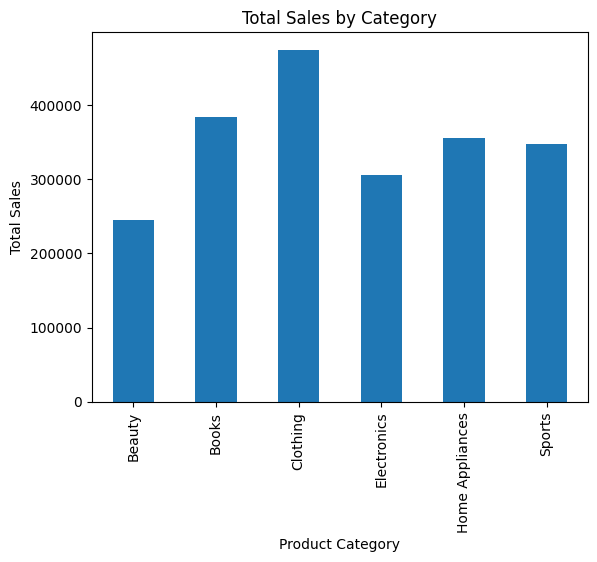

In [69]:
category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

### Plot a pie chart of customer distribution by Region.

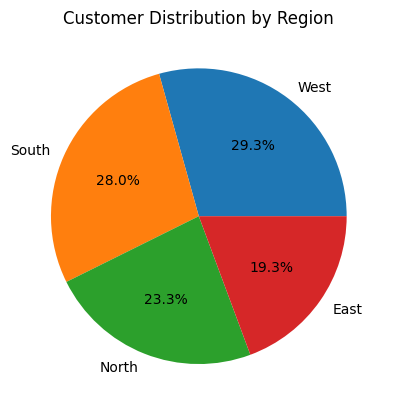

In [70]:
region_count = df["Region"].value_counts()

plt.pie(region_count, labels=region_count.index, autopct="%1.1f%%")

plt.title("Customer Distribution by Region")

plt.show()

### Plot a line chart of daily total sales over time.

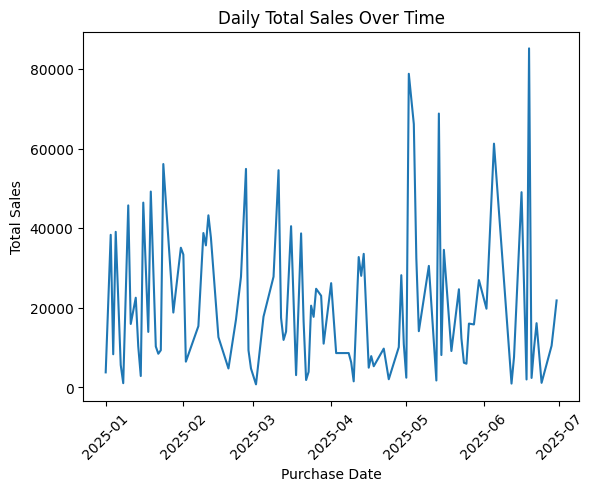

In [71]:
daily_sales = df.groupby("Purchase_Date")["Total_Amount"].sum()

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Daily Total Sales Over Time")
plt.xlabel("Purchase Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

## Seaborn Visualizations

### Use Seaborn: Create a box plot of Total_Amount by Gender.

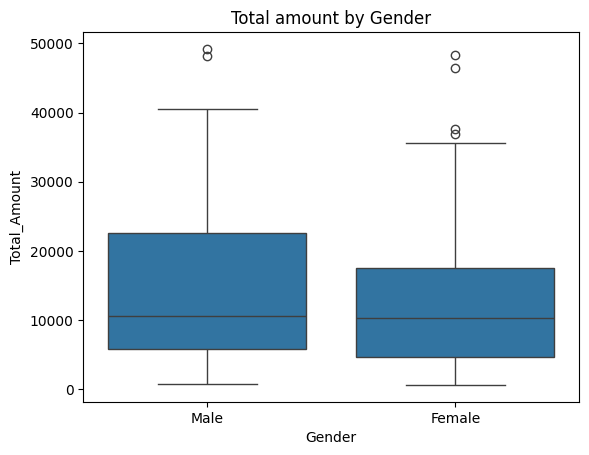

In [72]:
import seaborn as sns

sns.boxplot(x="Gender", y="Total_Amount", data=df)

plt.title("Total amount by Gender")

plt.show()

### Use Seaborn: Create a heatmap of correlation between numeric columns.

                      Age  Units_Purchased  Price_Per_Unit  Total_Amount  \
Age              1.000000        -0.116765       -0.119391     -0.154004   
Units_Purchased -0.116765         1.000000        0.070458      0.661727   
Price_Per_Unit  -0.119391         0.070458        1.000000      0.711189   
Total_Amount    -0.154004         0.661727        0.711189      1.000000   
Month            0.188940        -0.081502       -0.063797     -0.059142   

                    Month  
Age              0.188940  
Units_Purchased -0.081502  
Price_Per_Unit  -0.063797  
Total_Amount    -0.059142  
Month            1.000000  


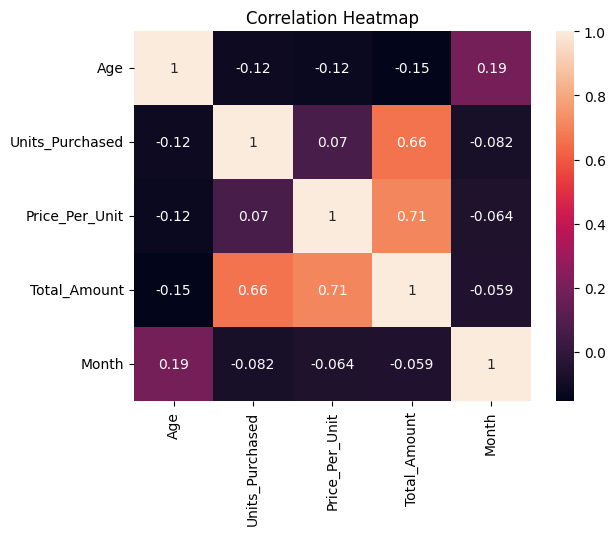

In [73]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print(correlation)

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")
plt.show()